In [26]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/yuanshanwu/Documents/GitHub/QuantUS/engines
/home/yuanshanwu/Documents/GitHub/QuantUS


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [27]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['mp4', 'nifti', 'avi']


In [28]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
}

In [29]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [30]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['load_bolus_mask', 'nifti']


In [31]:
seg_type = 'nifti'

seg_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/MotionCompensated_QUANTUSGUI.nii.gz'
seg_loader_kwargs = {}

In [32]:
from src.entrypoints import seg_loading_step

# Testing the motion compensation, right now is hard coded
seg_data = seg_loading_step(seg_type, image_data, seg_path, CEUS_scan_path, **seg_loader_kwargs)

# Implement MEDSAM 2 model

In [33]:
# Use inline backend - MORE RELIABLE for Jupyter
%matplotlib inline

import cv2
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
import imageio
from PIL import Image
import matplotlib.patches as patches
from tqdm import tqdm

def enhance_bmode_noise(image_slice, p_low_percentile=2.0, p_high_percentile=98.0):
    non_zero = image_slice[image_slice != 0]
    # Compute 10th and 90th percentile on non-zero values
    p_low = np.percentile(non_zero, 2)
    p_high = np.percentile(non_zero, 98)

    # Clip and normalize to 0-255
    clipped_slice = np.clip(image_slice, p_low, p_high)
    normalized_slice = ((clipped_slice - p_low) / (p_high - p_low) * 255).astype(np.uint8)
    
    return normalized_slice


def get_mask_boundary(mask_slice):
    """Extract boundary of a binary mask using erosion."""
    if mask_slice.max() == 0:
        return np.zeros_like(mask_slice, dtype=bool)
    eroded = binary_erosion(mask_slice)
    boundary = mask_slice.astype(bool) & ~eroded
    return boundary

def get_voi_center(mask_3d):
    """Calculate the center of a 3D VOI mask."""
    coords = np.where(mask_3d > 0)
    if len(coords[0]) == 0:
        return None, None, None
    lateral_center = int(np.mean(coords[0]))
    depth_center = int(np.mean(coords[1]))
    elevation_center = int(np.mean(coords[2]))
    return lateral_center, depth_center, elevation_center

In [36]:
import sys
# Add MedSAM2 root to Python path
# From CLI-Demos/, go up 4 levels to QUANTUS/, then into MedSAM2/
medsam2_path = os.path.abspath(os.path.join(os.getcwd(), 'MedSAM2'))
print(f"MedSAM2 path: {medsam2_path}")  # verify it looks right
sys.path.insert(0, medsam2_path)

# load libraries and define necessary functions
from glob import glob
from tqdm import tqdm
import os
from os.path import join, basename
import re
import matplotlib.pyplot as plt
from collections import OrderedDict
import pandas as pd
import numpy as np
import argparse

from PIL import Image
import SimpleITK as sitk
import torch
import torch.multiprocessing as mp
from sam2.build_sam import build_sam2_video_predictor_npz
import SimpleITK as sitk
from skimage import measure, morphology

MedSAM2 path: /home/yuanshanwu/Documents/GitHub/QuantUS/MedSAM2


## 3D segmentation using sagittal and coronal as the input for the bounding box
There are two way to approach this issue
1) We could segment out the axial,sagitall and coronal plane and then do an interpolation to 3d which is similar to what quantus have done.
2) we could use the x-plane information to generate an adaptive bounding box on the z plane where sagittal and coronal can provide x min to x max, y min to y max on each individual slice z. This way we are basically giving new bounding box information

In [93]:
import torch
import numpy as np
import os
os.environ["QT_API"] = "pyqt6"
import napari
import time
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ── Load model ────────────────────────────────────────────────────────────────
checkpoint = os.path.join(medsam2_path, 'checkpoints', 'MedSAM2_MRI_LiverLesion.pt')
model_cfg  = "configs/sam2.1_hiera_t512.yaml"
sam2_model = build_sam2(model_cfg, checkpoint, device="cuda")
image_predictor = SAM2ImagePredictor(sam2_model)

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def slice_to_rgb(slice_2d):
    """Normalize a 2D slice to uint8 RGB."""
    s_min, s_max = slice_2d.min(), slice_2d.max()
    uint8 = ((slice_2d - s_min) / (s_max - s_min + 1e-8) * 255).astype(np.uint8)
    return np.stack([uint8] * 3, axis=-1)


def run_medsam2_2d(image_predictor, slice_2d, bbox_2d, device="cuda"):
    """
    Run SAM2ImagePredictor on one 2D slice.
    slice_2d : (H, W) float   — already in display orientation
    bbox_2d  : [x_min, y_min, x_max, y_max]
    Returns  : (H, W) bool mask, or None if bbox is degenerate
    """
    # Skip degenerate bboxes (zero width or height)
    x_min, y_min, x_max, y_max = bbox_2d
    if (x_max - x_min) < 2 or (y_max - y_min) < 2:
        return None

    rgb = slice_to_rgb(slice_2d)
    with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
        image_predictor.set_image(rgb)
        masks, _, _ = image_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=np.array(bbox_2d, dtype=np.float32)[None, :],
            multimask_output=False,
        )
    return masks[0].astype(bool)                               # (H, W)


def get_adaptive_bbox_at_z(coronal_mask, sagittal_mask, z_abs, bbox, padding=4):
    """
    Derive a tight 2D bbox for axial slice at z_abs using coronal + sagittal masks.

    coronal_mask  : (X, Z) — from SAM2 on volume[:, y_mid, :]
    sagittal_mask : (Y, Z) — from SAM2 on volume[x_mid, :, :]
    z_abs         : absolute Z index in the full volume
    bbox          : BoundingBox3D — used for z_min offset and fallback bounds
    padding       : extra pixels added around the derived bbox

    Returns: [x_min, y_min, x_max, y_max] or None if no mask at this z
    """
    z_rel = z_abs                    # relative index into coronal/sagittal masks

    # X extent from coronal mask (X, Z) — which X pixels are active at this z?
    coronal_col = coronal_mask[:, int(z_rel)]          # (X,)
    x_active    = np.where(coronal_col)[0]

    # Y extent from sagittal mask (Y, Z) — which Y pixels are active at this z?
    sagittal_col = sagittal_mask[:, int(z_rel)]        # (Y,)
    y_active     = np.where(sagittal_col)[0]

    # If either plane has no active pixels at this Z, skip the slice
    if len(x_active) == 0 or len(y_active) == 0:
        return None

    # Build tight bbox with padding, clamped to volume bounds
    x_min = max(0,               x_active.min() - padding)
    x_max = min(bbox.x_max + padding, x_active.max() + padding)
    y_min = max(0,               y_active.min() - padding)
    y_max = min(bbox.y_max + padding, y_active.max() + padding)

    return [x_min, y_min, x_max, y_max]


# ─────────────────────────────────────────────────────────────────────────────
# Main: single frame 3D segmentation
# ─────────────────────────────────────────────────────────────────────────────
frame_idx = 0                                     # ← change to any frame you want

bbox    = seg_data.motion_compensation.tracked_bboxes[frame_idx]
volume  = bmode_image_data.pixel_data[:, :, :, frame_idx]      # (X, Y, Z)
mc_mask = seg_data.motion_compensation.apply_to_mask(
              seg_data.seg_mask, frame_idx, 0)                  # (X, Y, Z)

# Derive best slice centres from MC mask
z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
y_mid = int(np.argmax(mc_mask.sum(axis=(0, 2))))
x_mid = int(np.argmax(mc_mask.sum(axis=(1, 2))))

print(f"Frame {frame_idx} | z_mid={z_mid}  y_mid={y_mid}  x_mid={x_mid}")
print(f"BBox: X=[{bbox.x_min},{bbox.x_max}]  "
      f"Y=[{bbox.y_min},{bbox.y_max}]  "
      f"Z=[{bbox.z_min},{bbox.z_max}]")

start_time = time.time()
# ── Step 1: Segment coronal at y_mid → (X, Z) ────────────────────────────────
print("\nStep 1: Segmenting coronal plane...")
coronal_slice = volume[:, y_mid, :]                            # (X, Z)
coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                           bbox.z_max, bbox.x_max], dtype=np.float32)
coronal_mask  = run_medsam2_2d(image_predictor, coronal_slice, coronal_bbox)
# coronal_mask shape: (X, Z) — H=X rows, W=Z cols in display, so transpose back
# run_medsam2_2d returns (H, W) = (X, Z) since we did NOT transpose coronal_slice
# coronal_mask is already (X, Z) ✓
print(f"  Coronal mask: {coronal_mask.sum()} active pixels")

# ── Step 2: Segment sagittal at x_mid → (Y, Z) ───────────────────────────────
print("\nStep 2: Segmenting sagittal plane...")
sagittal_slice = volume[x_mid, :, :]                           # (Y, Z)
sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                            bbox.z_max, bbox.y_max], dtype=np.float32)
sagittal_mask  = run_medsam2_2d(image_predictor, sagittal_slice, sagittal_bbox)
# sagittal_mask is (Y, Z) ✓
print(f"  Sagittal mask: {sagittal_mask.sum()} active pixels")

# ── Step 3: Per-axial-slice segmentation with adaptive bbox ───────────────────
print(f"\nStep 3: Segmenting axial slices z={bbox.z_min} → z={bbox.z_max}...")
mask_3d = np.zeros(volume.shape, dtype=np.uint8)               # (X, Y, Z)

n_segmented = 0
n_skipped   = 0
save_adaptive_bbox = np.zeros((4, int(bbox.z_max - bbox.z_min)))

for abs_z in range(int(bbox.z_min), int(bbox.z_max)):

    # Derive slice-specific bbox from coronal + sagittal guidance
    adaptive_bbox = get_adaptive_bbox_at_z(
        coronal_mask, sagittal_mask, abs_z, bbox, padding=0
    )

    if adaptive_bbox is None:
        n_skipped += 1
        continue                                               # leave as zeros

    # Axial slice — transpose to (Y, X) to match visualization convention
    axial_slice = volume[:, :, abs_z].T                        # (Y, X)

    # Run SAM2 — bbox is [x_min, y_min, x_max, y_max] in (Y, X) image space
    # x→col=X(lateral), y→row=Y(depth) after transpose ✓
    pred_yx = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

    save_adaptive_bbox[:,abs_z-int(bbox.z_min)] = adaptive_bbox
    
    if pred_yx is not None:
        mask_3d[:, :, abs_z] = pred_yx.T                      # (Y,X)→(X,Y)
        n_segmented += 1
    else:
        n_skipped += 1

elapsed = time.time() - start_time
print(f"\nInference completed in {elapsed:.1f} seconds")
print(f"  Segmented: {n_segmented} slices  |  Skipped: {n_skipped} slices")
print(f"  3D mask active voxels: {mask_3d.sum()}")

Frame 0 | z_mid=86  y_mid=120  x_mid=219
BBox: X=[170.0,257.0]  Y=[89.0,155.0]  Z=[46.0,133.0]

Step 1: Segmenting coronal plane...
  Coronal mask: 4816 active pixels

Step 2: Segmenting sagittal plane...
  Sagittal mask: 3613 active pixels

Step 3: Segmenting axial slices z=46.0 → z=133.0...

Inference completed in 0.7 seconds
  Segmented: 74 slices  |  Skipped: 13 slices
  3D mask active voxels: 138699


In [94]:
# ─────────────────────────────────────────────────────────────────────────────
# Napari visualization
# ─────────────────────────────────────────────────────────────────────────────
print("\nLaunching napari...")

# Napari expects (Z, Y, X) for standard volume display
# Our volume is (X, Y, Z) → transpose to (Z, Y, X)
volume_zyx  = volume.T                                         # (Z, Y, X)
sam2_zyx    = mask_3d.T.astype(np.uint8)                       # (Z, Y, X)
mc_zyx      = mc_mask.T.astype(np.uint8)                       # (Z, Y, X)

viewer = napari.Viewer(title=f"MedSAM2 3D vs MC mask — Frame {frame_idx}")

# B-mode volume
viewer.add_image(
    volume_zyx,
    name="B-mode volume",
    colormap="gray",
    blending="additive",
)

# MC mask — red, semi-transparent
viewer.add_labels(
    mc_zyx,
    name="MC mask (reference)",
    opacity=0.4,
)

# MedSAM2 3D mask — green, semi-transparent
viewer.add_labels(
    sam2_zyx,
    name="MedSAM2 3D mask",
    opacity=0.4,
)

# Show the guidance planes as image layers for reference
viewer.add_image(
    coronal_slice.T,                                           # napari wants (Z, X) for a ZX plane
    name=f"Coronal slice (Y={y_mid})",
    colormap="gray",
    visible=False,                                             # hidden by default, toggle in GUI
)

napari.run()


Launching napari...


## Visualizing how the bounding box being predicted

In [95]:
# ── Fixed get_adaptive_bbox_at_z — use z_abs directly ────────────────────────
def get_adaptive_bbox_at_z(coronal_mask, sagittal_mask, z_abs, bbox, padding=4):
    """
    coronal_mask  : (X, Z_full) — full volume Z space
    sagittal_mask : (Y, Z_full) — full volume Z space
    z_abs         : absolute Z index — used directly, no offset
    """
    # X extent from coronal mask at z_abs directly
    coronal_col  = coronal_mask[:, z_abs]       # (X,)
    x_active     = np.where(coronal_col)[0]

    # Y extent from sagittal mask at z_abs directly
    sagittal_col = sagittal_mask[:, z_abs]      # (Y,)
    y_active     = np.where(sagittal_col)[0]

    if len(x_active) == 0 or len(y_active) == 0:
        return None

    x_min = max(0,                 x_active.min() - padding)
    x_max = min(volume.shape[0],   x_active.max() + padding)
    y_min = max(0,                 y_active.min() - padding)
    y_max = min(volume.shape[1],   y_active.max() + padding)

    return [x_min, y_min, x_max, y_max]


# ── Rebuild mask_3d with fix + save adaptive bboxes ───────────────────────────
mask_3d          = np.zeros(volume.shape, dtype=np.uint8)  # (X, Y, Z)
saved_adaptive_bboxes = {}   # abs_z → [x_min, y_min, x_max, y_max]

n_segmented = 0
n_skipped   = 0

for abs_z in range(int(bbox.z_min), int(bbox.z_max)):

    adaptive_bbox = get_adaptive_bbox_at_z(
        coronal_mask, sagittal_mask, abs_z, bbox, padding=4
    )

    if adaptive_bbox is None:
        n_skipped += 1
        continue

    saved_adaptive_bboxes[abs_z] = adaptive_bbox   # save for visualization

    axial_slice = volume[:, :, abs_z].T             # (Y, X)
    pred_yx     = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

    if pred_yx is not None:
        mask_3d[:, :, abs_z] = pred_yx.T           # (Y, X) → (X, Y)
        n_segmented += 1
    else:
        n_skipped += 1

print(f"Segmented: {n_segmented}  |  Skipped: {n_skipped}")
print(f"3D mask active voxels: {mask_3d.sum()}")
print(f"Saved adaptive bboxes: {len(saved_adaptive_bboxes)} slices")


# ── Napari visualization ───────────────────────────────────────────────────────
import napari
import numpy as np

viewer = napari.Viewer(title=f"Adaptive BBox debug — Frame {frame_idx}")

# B-mode volume — (Z, Y, X)
viewer.add_image(
    volume.T,
    name="B-mode volume",
    colormap="gray",
    blending="additive",
)

# MC mask reference — red
viewer.add_labels(
    mc_mask.T.astype(np.uint8),
    name="MC mask (reference)",
    opacity=0.5,
)

# MedSAM2 3D mask — green
viewer.add_labels(
    mask_3d.T.astype(np.uint8),
    name="MedSAM2 3D mask",
    opacity=0.5,
)

# ── Draw adaptive bboxes as rectangles in napari shapes layer ─────────────────
# napari shapes use (Z, Y, X) coordinates
# Each rectangle is defined by 4 corners: top-left, top-right, bottom-right, bottom-left
rectangles = []
for abs_z, (x_min, y_min, x_max, y_max) in saved_adaptive_bboxes.items():
    rect = np.array([
        [abs_z, y_min, x_min],   # top-left
        [abs_z, y_min, x_max],   # top-right
        [abs_z, y_max, x_max],   # bottom-right
        [abs_z, y_max, x_min],   # bottom-left
    ])
    rectangles.append(rect)

viewer.add_shapes(
    rectangles,
    shape_type="polygon",
    edge_color="cyan",
    face_color="transparent",
    edge_width=1,
    name="Adaptive bbox per Z slice",
)

# Original 3D bbox — yellow
orig_bbox_corners = [
    np.array([
        [bbox.z_min, bbox.y_min, bbox.x_min],
        [bbox.z_min, bbox.y_min, bbox.x_max],
        [bbox.z_min, bbox.y_max, bbox.x_max],
        [bbox.z_min, bbox.y_max, bbox.x_min],
    ]),
    np.array([
        [bbox.z_max, bbox.y_min, bbox.x_min],
        [bbox.z_max, bbox.y_min, bbox.x_max],
        [bbox.z_max, bbox.y_max, bbox.x_max],
        [bbox.z_max, bbox.y_max, bbox.x_min],
    ]),
]

viewer.add_shapes(
    orig_bbox_corners,
    shape_type="polygon",
    edge_color="yellow",
    face_color="transparent",
    edge_width=2,
    name="Original 3D bbox",
)

# Set viewer to z_mid
z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
viewer.dims.current_step = (z_mid, 0, 0)

print(f"\nNapari launched")
print(f"  Cyan   = adaptive bbox per Z slice (should taper toward edges)")
print(f"  Yellow = original 3D bbox faces at z_min and z_max")
print(f"  Red    = MC mask reference")
print(f"  Green  = MedSAM2 3D mask")

Segmented: 74  |  Skipped: 13
3D mask active voxels: 171734
Saved adaptive bboxes: 74 slices

Napari launched
  Cyan   = adaptive bbox per Z slice (should taper toward edges)
  Yellow = original 3D bbox faces at z_min and z_max
  Red    = MC mask reference
  Green  = MedSAM2 3D mask


## Adding in the 4D movement of the tumor

In [88]:
import os
os.environ["QT_API"] = "pyqt6"

import napari
import numpy as np
import torch
from functools import lru_cache

# ── Cache to avoid recomputing visited frames ─────────────────────────────────
frame_cache = {}

def compute_frame(frame_idx):
    """Compute SAM2 3D mask for a single frame. Uses cache if available."""
    if frame_idx in frame_cache:
        return frame_cache[frame_idx]

    bbox    = seg_data.motion_compensation.tracked_bboxes[frame_idx]
    volume  = bmode_image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    mc_mask = seg_data.motion_compensation.apply_to_mask(
                  seg_data.seg_mask, frame_idx, 0)              # (X, Y, Z)

    # Best slice centres from MC mask
    z_mid = int(np.argmax(mc_mask.sum(axis=(0, 1))))
    y_mid = int(np.argmax(mc_mask.sum(axis=(0, 2))))
    x_mid = int(np.argmax(mc_mask.sum(axis=(1, 2))))

    # Step 1: coronal guidance
    coronal_slice = volume[:, y_mid, :]
    coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                               bbox.z_max, bbox.x_max], dtype=np.float32)
    coronal_mask  = run_medsam2_2d(image_predictor, coronal_slice, coronal_bbox)

    # Step 2: sagittal guidance
    sagittal_slice = volume[x_mid, :, :]
    sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                                bbox.z_max, bbox.y_max], dtype=np.float32)
    sagittal_mask  = run_medsam2_2d(image_predictor, sagittal_slice, sagittal_bbox)

    # Step 3: per-axial-slice segmentation with adaptive bbox
    mask_3d = np.zeros(volume.shape, dtype=np.uint8)  # (X, Y, Z)

    for abs_z in range(int(bbox.z_min), int(bbox.z_max)):
        adaptive_bbox = get_adaptive_bbox_at_z(
            coronal_mask, sagittal_mask, abs_z, bbox, padding=4
        )
        if adaptive_bbox is None:
            continue

        axial_slice = volume[:, :, abs_z].T            # (Y, X)
        pred_yx     = run_medsam2_2d(image_predictor, axial_slice, adaptive_bbox)

        if pred_yx is not None:
            mask_3d[:, :, abs_z] = pred_yx.T          # (Y, X) → (X, Y)

    # Cache result
    frame_cache[frame_idx] = {
        "volume":   volume,
        "mc_mask":  mc_mask,
        "sam2_mask": mask_3d,
    }

    return frame_cache[frame_idx]


# ── Precompute frame 0 to initialise the viewer ───────────────────────────────
print("Computing frame 0...")
result      = compute_frame(0)
volume_zyx  = result["volume"].T.astype(np.float32)    # (Z, Y, X)
mc_zyx      = result["mc_mask"].T.astype(np.uint8)     # (Z, Y, X)
sam2_zyx    = result["sam2_mask"].T.astype(np.uint8)   # (Z, Y, X)
print("Done. Launching napari...")

# ── Launch napari ──────────────────────────────────────────────────────────────
viewer = napari.Viewer(title="MedSAM2 3D — on-demand segmentation")

bmode_layer = viewer.add_image(
    volume_zyx,
    name="B-mode volume",
    colormap="gray",
    blending="additive",
)

mc_layer = viewer.add_labels(
    mc_zyx,
    name="MC mask (reference)",
    opacity=0.5,
)

sam2_layer = viewer.add_labels(
    sam2_zyx,
    name="MedSAM2 3D mask",
    opacity=0.5,
)

# Status label in napari
status_label = viewer.text_overlay
status_label.visible = True
status_label.text    = "Frame 0 — ready"

# ── Callback: fires when the T slider changes ──────────────────────────────────
# We add a dummy T dimension so napari gives us a frame slider
# Wrap each layer as (T=1, Z, Y, X) — napari will show a T slider
# once we update dynamically

current_frame = {"idx": 0}   # mutable container to track state

def on_frame_change(event):
    """Called when user drags the frame slider."""
    # napari dims order for a 3D volume is (Z, Y, X)
    # We use a separate IntSlider widget for frame control
    pass  # replaced by the slider below

# ── Add a frame slider as a napari dock widget ────────────────────────────────
from qtpy.QtWidgets import QSlider, QLabel, QVBoxLayout, QWidget
from qtpy.QtCore    import Qt

n_frames = bmode_image_data.pixel_data.shape[-1]

class FrameControlWidget(QWidget):
    def __init__(self):
        super().__init__()
        layout = QVBoxLayout()

        self.label = QLabel("Frame: 0")
        self.label.setAlignment(Qt.AlignmentFlag.AlignCenter)

        self.slider = QSlider(Qt.Orientation.Horizontal)
        self.slider.setMinimum(0)
        self.slider.setMaximum(n_frames - 1)
        self.slider.setValue(0)
        self.slider.setTickInterval(10)
        self.slider.setTickPosition(QSlider.TickPosition.TicksBelow)

        self.slider.valueChanged.connect(self.on_slider_changed)

        layout.addWidget(self.label)
        layout.addWidget(self.slider)
        self.setLayout(layout)

    def on_slider_changed(self, frame_idx):
        self.label.setText(f"Frame: {frame_idx}  (computing...)")

        # Compute or retrieve from cache
        result = compute_frame(frame_idx)

        # Update layers in place — no viewer restart needed
        bmode_layer.data = result["volume"].T.astype(np.float32)
        mc_layer.data    = result["mc_mask"].T.astype(np.uint8)
        sam2_layer.data  = result["sam2_mask"].T.astype(np.uint8)

        self.label.setText(
            f"Frame: {frame_idx}  |  "
            f"SAM2 voxels: {result['sam2_mask'].sum()}  |  "
            f"MC voxels: {result['mc_mask'].sum()}"
        )

frame_widget = FrameControlWidget()
viewer.window.add_dock_widget(
    frame_widget,
    name="Frame Control",
    area="bottom",
)

print(f"Napari ready — {n_frames} frames available")
print("Use the bottom slider to scrub through frames")

Computing frame 0...
Done. Launching napari...
Napari ready — 530 frames available
Use the bottom slider to scrub through frames


## Inference MedSAM2 on 2D image X-plane

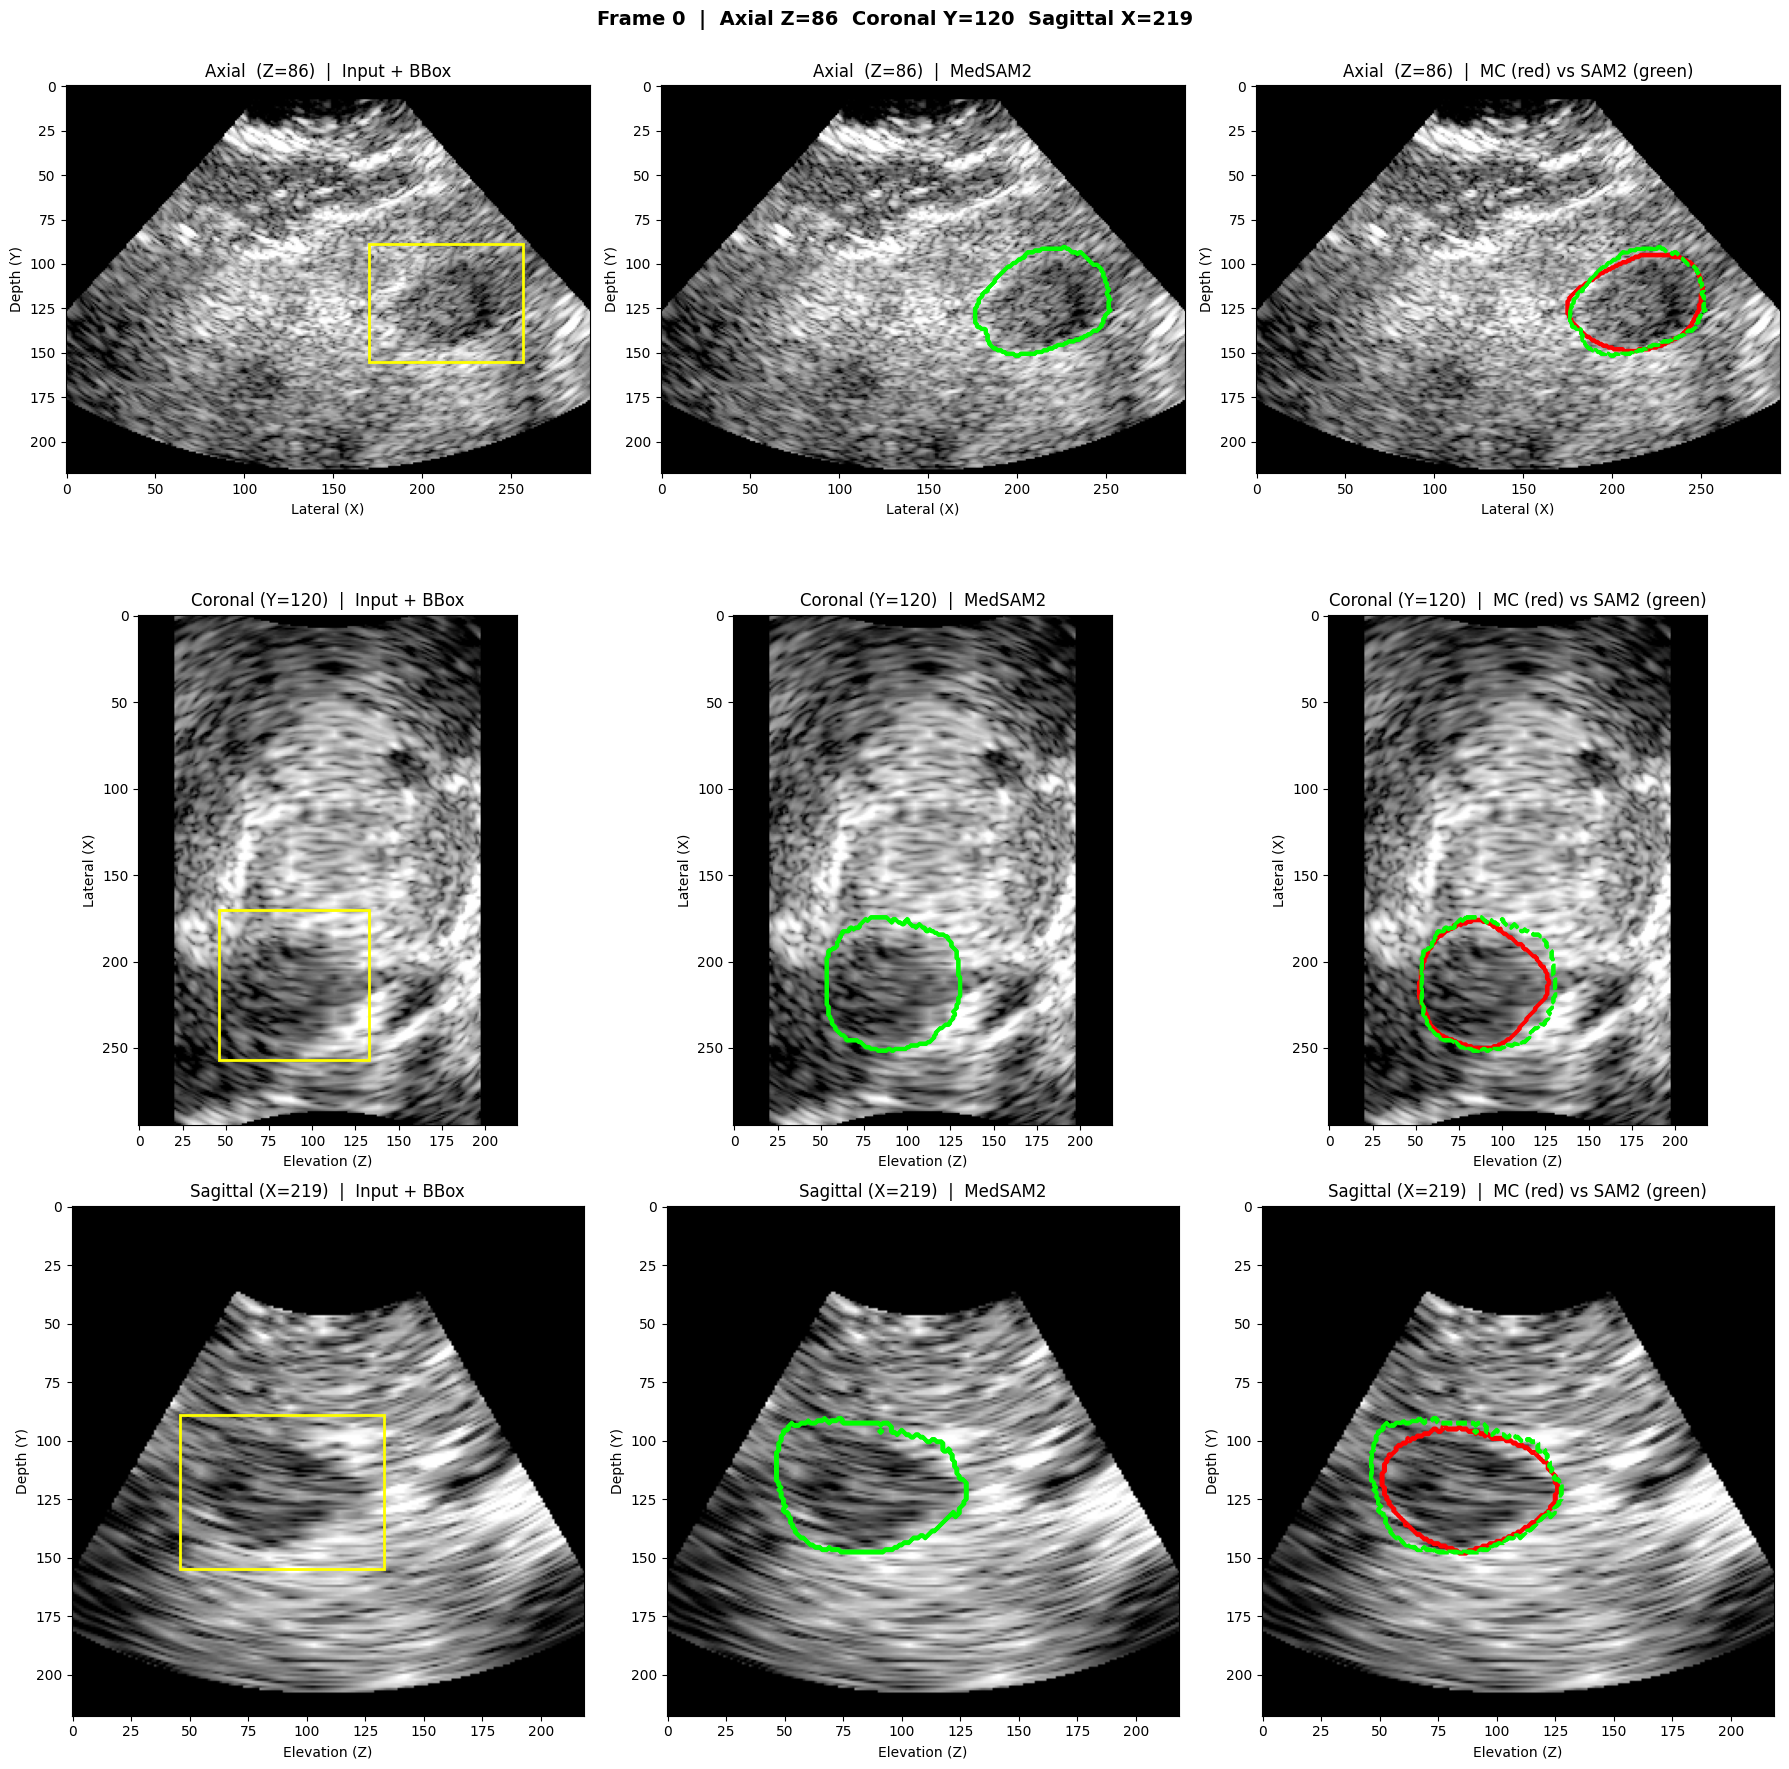

MedSAM2 3-plane segmentation: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s]


In [92]:
# 2D inference on all 3 planes (axial, coronal, sagittal) for a single frame
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from tqdm import tqdm
from IPython.display import clear_output

# Load model
checkpoint = os.path.join(medsam2_path, 'checkpoints', 'MedSAM2_MRI_LiverLesion.pt')
model_cfg = "configs/sam2.1_hiera_t512.yaml"
sam2_model = build_sam2(model_cfg, checkpoint)
image_predictor = SAM2ImagePredictor(sam2_model)

def slice_to_rgb(slice_2d):
    """Normalize a 2D slice to uint8 RGB for MedSAM2."""
    s_min, s_max = slice_2d.min(), slice_2d.max()
    uint8 = ((slice_2d - s_min) / (s_max - s_min + 1e-8) * 255).astype(np.uint8)
    return np.stack([uint8] * 3, axis=-1)

def run_medsam2(image_predictor, slice_rgb, bbox_2d):
    """Run MedSAM2 on a single 2D slice with a bounding box prompt."""
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        image_predictor.set_image(slice_rgb)
        masks, scores, logits = image_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=bbox_2d[None, :],  # (1, 4)
            multimask_output=False,
        )
    return masks[0]  # (H, W) binary mask

start_frame = 0
end_frame = 1

for frame_idx in tqdm(range(start_frame, end_frame), desc="MedSAM2 3-plane segmentation"):
    clear_output(wait=True)

    bbox  = seg_data.motion_compensation.tracked_bboxes[frame_idx]
    volume = bmode_image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
    mc_mask = seg_data.motion_compensation.apply_to_mask(seg_data.seg_mask, frame_idx, 0)  # (X, Y, Z)

    # ------------------------------------------------------------------ #
    # Derive slice centres from MC mask (more reliable than bbox midpoint)#
    # ------------------------------------------------------------------ #
    z_mid = np.argmax(mc_mask.sum(axis=(0, 1)))   # elevation slice with most voxels
    y_mid = np.argmax(mc_mask.sum(axis=(0, 2)))   # depth slice
    x_mid = np.argmax(mc_mask.sum(axis=(1, 2)))   # lateral slice

    # ================================================================== #
    # AXIAL VIEW  –  volume[:, :, z_mid] → transpose to (Y, X)           #
    # bbox: x→col (lateral), y→row (depth)  ✓ already correct after .T   #
    # ================================================================== #
    axial_slice = volume[:, :, z_mid].T                          # (Y, X)
    axial_rgb   = slice_to_rgb(axial_slice)
    axial_bbox  = np.array([bbox.x_min, bbox.y_min,
                            bbox.x_max, bbox.y_max], dtype=np.float32)
    axial_pred  = run_medsam2(image_predictor, axial_rgb, axial_bbox)
    axial_mc    = mc_mask[:, :, z_mid].T                         # (Y, X)

    # ================================================================== #
    # CORONAL VIEW  –  volume[:, y_mid, :] → shape (X, Z), no transpose  #
    # image axes: col=Z (elevation), row=X (lateral)                      #
    # bbox prompt: x→col=Z, y→row=X                                       #
    # ================================================================== #
    coronal_slice = volume[:, y_mid, :]                          # (X, Z)
    coronal_rgb   = slice_to_rgb(coronal_slice)
    coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                              bbox.z_max, bbox.x_max], dtype=np.float32)
    coronal_pred  = run_medsam2(image_predictor, coronal_rgb, coronal_bbox)
    coronal_mc    = mc_mask[:, y_mid, :]                         # (X, Z)

    # ================================================================== #
    # SAGITTAL VIEW  –  volume[x_mid, :, :] → shape (Y, Z), no transpose #
    # image axes: col=Z (elevation), row=Y (depth)                        #
    # bbox prompt: x→col=Z, y→row=Y                                       #
    # ================================================================== #
    sagittal_slice = volume[x_mid, :, :]                         # (Y, Z)
    sagittal_rgb   = slice_to_rgb(sagittal_slice)
    sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                               bbox.z_max, bbox.y_max], dtype=np.float32)
    sagittal_pred  = run_medsam2(image_predictor, sagittal_rgb, sagittal_bbox)
    sagittal_mc    = mc_mask[x_mid, :, :]                        # (Y, Z)

    fig, axes = plt.subplots(3, 3, figsize=(18, 18))

    views = [
        {
            "label":  f"Axial  (Z={z_mid})",
            "xlabel": "Lateral (X)",
            "ylabel": "Depth (Y)",
            "slice":  axial_slice,
            "pred":   axial_pred,
            "mc":     axial_mc,
            "rect":   patches.Rectangle(
                          (bbox.x_min, bbox.y_min),
                          bbox.x_max - bbox.x_min,
                          bbox.y_max - bbox.y_min,
                          edgecolor='yellow', facecolor='none', linewidth=2),
        },
        {
            "label":  f"Coronal (Y={y_mid})",
            "xlabel": "Elevation (Z)",
            "ylabel": "Lateral (X)",
            "slice":  coronal_slice,
            "pred":   coronal_pred,
            "mc":     coronal_mc,
            "rect":   patches.Rectangle(
                          (bbox.z_min, bbox.x_min),
                          bbox.z_max - bbox.z_min,
                          bbox.x_max - bbox.x_min,
                          edgecolor='yellow', facecolor='none', linewidth=2),
        },
        {
            "label":  f"Sagittal (X={x_mid})",
            "xlabel": "Elevation (Z)",
            "ylabel": "Depth (Y)",
            "slice":  sagittal_slice,
            "pred":   sagittal_pred,
            "mc":     sagittal_mc,
            "rect":   patches.Rectangle(
                          (bbox.z_min, bbox.y_min),
                          bbox.z_max - bbox.z_min,
                          bbox.y_max - bbox.y_min,
                          edgecolor='yellow', facecolor='none', linewidth=2),
        },
    ]

    for row, v in enumerate(views):
        img_disp = enhance_bmode_noise(v["slice"])

        # --- col 0: input + bbox ---
        axes[row, 0].imshow(img_disp, cmap='gray')
        axes[row, 0].add_patch(v["rect"])
        axes[row, 0].set_title(f'{v["label"]}  |  Input + BBox')
        axes[row, 0].set_xlabel(v["xlabel"])
        axes[row, 0].set_ylabel(v["ylabel"])

        # --- col 1: MedSAM2 overlay ---
        axes[row, 1].imshow(img_disp, cmap='gray')
        axes[row, 1].contour(v["pred"], colors='lime', linewidths=2)
        axes[row, 1].set_title(f'{v["label"]}  |  MedSAM2')
        axes[row, 1].set_xlabel(v["xlabel"])
        axes[row, 1].set_ylabel(v["ylabel"])

        # --- col 2: MC mask (red) vs MedSAM2 (green dashed) ---
        axes[row, 2].imshow(img_disp, cmap='gray')
        axes[row, 2].contour(get_mask_boundary(v["mc"].astype(bool)),
                             colors='red', linewidths=2)
        axes[row, 2].contour(v["pred"],
                             colors='lime', linewidths=2, linestyles='dashed')
        axes[row, 2].set_title(f'{v["label"]}  |  MC (red) vs SAM2 (green)')
        axes[row, 2].set_xlabel(v["xlabel"])
        axes[row, 2].set_ylabel(v["ylabel"])

    fig.suptitle(f'Frame {frame_idx}  |  Axial Z={z_mid}  Coronal Y={y_mid}  Sagittal X={x_mid}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [114]:
import pyvista as pv
import scipy.interpolate as interpolate
from scipy.spatial import ConvexHull
from scipy.ndimage import binary_fill_holes

def calculateSpline3D(points):
    cloud = pv.PolyData(points, force_float=False)
    volume = cloud.delaunay_3d(alpha=100)
    shell = volume.extract_geometry() # type: ignore
    final = shell.triangulate() # type: ignore
    final.smooth(n_iter=1000) # type: ignore
    faces = final.faces.reshape((-1, 4)) # type: ignore
    faces = faces[:, 1:]
    arr = final.points[faces] # type: ignore

    arr = np.array(arr)

    output = set()
    for tri in arr:
        slope_2 = tri[2] - tri[1]
        start_2 = tri[1]
        slope_3 = tri[0] - tri[1]
        start_3 = tri[1]
        for i in range(100, -1, -1):
            bound_one = start_2 + ((i / 100) * slope_2)
            bound_two = start_3 + ((i / 100) * slope_3)
            cur_slope = bound_one - bound_two
            cur_start = bound_two
            for j in range(100, -1, -1):
                cur_pos = cur_start + ((j / 100) * cur_slope)
                output.add((int(cur_pos[0]), int(cur_pos[1]), int(cur_pos[2])))

    return output

def _smooth_3d_mask(mask: np.ndarray) -> np.ndarray:
    """Apply 3D smoothing to the binary mask."""
    mask = binary_fill_holes(mask)
    for i in range(mask.shape[2]):
        border = np.where(mask[:, :, i] == 1)
        if (
            (not len(border[0]))
            or (max(border[0]) == min(border[0]))
            or (max(border[1]) == min(border[1]))
        ):
            continue
        border = np.array(border).T
        hull = ConvexHull(border)
        vertices = border[hull.vertices]
        shape = vertices.shape
        vertices = np.reshape(
            np.append(vertices, vertices[0]), (shape[0] + 1, shape[1])
        )

        # Linear interpolation of 2d convex hull
        tck, _ = interpolate.splprep(vertices.T, s=0.0, k=1)
        splineX, splineY = np.array(
            interpolate.splev(np.linspace(0, 1, 1000), tck)
        )

        mask[:, :, i] = np.zeros((mask.shape[0], mask.shape[1]))
        for j in range(len(splineX)):
            mask[int(splineX[j]), int(splineY[j]), i] = 1
        mask[:, :, i] = binary_fill_holes(mask[:, :, i])

    return mask


bbox  = seg_data.motion_compensation.tracked_bboxes[frame_idx]
volume = bmode_image_data.pixel_data[:, :, :, frame_idx]  # (X, Y, Z)
mc_mask = seg_data.motion_compensation.apply_to_mask(seg_data.seg_mask, frame_idx, 0)  # (X, Y, Z)

# ------------------------------------------------------------------ #
# Derive slice centres from MC mask (more reliable than bbox midpoint)#
# ------------------------------------------------------------------ #
z_mid = np.argmax(mc_mask.sum(axis=(0, 1)))   # elevation slice with most voxels
y_mid = np.argmax(mc_mask.sum(axis=(0, 2)))   # depth slice
x_mid = np.argmax(mc_mask.sum(axis=(1, 2)))   # lateral slice

# ================================================================== #
# AXIAL VIEW  –  volume[:, :, z_mid] → transpose to (Y, X)           #
# bbox: x→col (lateral), y→row (depth)  ✓ already correct after .T   #
# ================================================================== #
axial_slice = volume[:, :, z_mid].T                          # (Y, X)
axial_rgb   = slice_to_rgb(axial_slice)
axial_bbox  = np.array([bbox.x_min, bbox.y_min,
                        bbox.x_max, bbox.y_max], dtype=np.float32)
axial_pred  = run_medsam2(image_predictor, axial_rgb, axial_bbox)
axial_mc    = mc_mask[:, :, z_mid].T                         # (Y, X)

# ================================================================== #
# CORONAL VIEW  –  volume[:, y_mid, :] → shape (X, Z), no transpose  #
# image axes: col=Z (elevation), row=X (lateral)                      #
# bbox prompt: x→col=Z, y→row=X                                       #
# ================================================================== #
coronal_slice = volume[:, y_mid, :]                          # (X, Z)
coronal_rgb   = slice_to_rgb(coronal_slice)
coronal_bbox  = np.array([bbox.z_min, bbox.x_min,
                            bbox.z_max, bbox.x_max], dtype=np.float32)
coronal_pred  = run_medsam2(image_predictor, coronal_rgb, coronal_bbox)
coronal_mc    = mc_mask[:, y_mid, :]                         # (X, Z)

# ================================================================== #
# SAGITTAL VIEW  –  volume[x_mid, :, :] → shape (Y, Z), no transpose #
# image axes: col=Z (elevation), row=Y (depth)                        #
# bbox prompt: x→col=Z, y→row=Y                                       #
# ================================================================== #
sagittal_slice = volume[x_mid, :, :]                         # (Y, Z)
sagittal_rgb   = slice_to_rgb(sagittal_slice)
sagittal_bbox  = np.array([bbox.z_min, bbox.y_min,
                            bbox.z_max, bbox.y_max], dtype=np.float32)
sagittal_pred  = run_medsam2(image_predictor, sagittal_rgb, sagittal_bbox)
sagittal_mc    = mc_mask[x_mid, :, :]                        # (Y, Z)

# Extract boundary points from the three masks
# axial_pred (Y, X) at z_mid
# argwhere gives (row, col) = (Y, X)
# → volume coords (X, Y, Z) = (col, row, z_mid)
axial_pts = np.argwhere(axial_pred)          # (N, 2) → (Y, X)
axial_3d  = np.column_stack([
    axial_pts[:, 1],                          # X = col
    axial_pts[:, 0],                          # Y = row
    np.full(len(axial_pts), z_mid),           # Z = z_mid
])                                            # (N, 3) in (X, Y, Z)

# coronal_pred (X, Z) at y_mid
# argwhere gives (row, col) = (X, Z)
# → volume coords (X, Y, Z) = (row, y_mid, col)
coronal_pts = np.argwhere(coronal_pred)       # (N, 2) → (X, Z)
coronal_3d  = np.column_stack([
    coronal_pts[:, 0],                        # X = row
    np.full(len(coronal_pts), y_mid),         # Y = y_mid
    coronal_pts[:, 1],                        # Z = col
])                                            # (N, 3) in (X, Y, Z)

# sagittal_pred (Y, Z) at x_mid
# argwhere gives (row, col) = (Y, Z)
# → volume coords (X, Y, Z) = (x_mid, row, col)
sagittal_pts = np.argwhere(sagittal_pred)     # (N, 2) → (Y, Z)
sagittal_3d  = np.column_stack([
    np.full(len(sagittal_pts), x_mid),        # X = x_mid
    sagittal_pts[:, 0],                       # Y = row
    sagittal_pts[:, 1],                       # Z = col
])                                            # (N, 3) in (X, Y, Z)

# Combine all three planes into one point cloud
all_points = np.vstack([axial_3d, coronal_3d, sagittal_3d])  # (N_total, 3)
all_points_clean = np.unique(all_points, axis=0)  # Remove duplicates
print(f"Total unique boundary points from all planes: {len(all_points_clean)}")

Total unique boundary points from all planes: 11569


In [ ]:
output = calculateSpline3D(all_points_clean)

# ── Build 3D mask ─────────────────────────────────────────────────────────────
X_len, Y_len, Z_len = volume.shape
interp_mask = np.zeros((X_len, Y_len, Z_len), dtype=bool)

interp_points = np.round(np.array(list(output))).astype(int)
interp_points[:, 0] = np.clip(interp_points[:, 0], 0, X_len - 1)
interp_points[:, 1] = np.clip(interp_points[:, 1], 0, Y_len - 1)
interp_points[:, 2] = np.clip(interp_points[:, 2], 0, Z_len - 1)

interp_mask[interp_points[:, 0],
            interp_points[:, 1],
            interp_points[:, 2]] = True

interp_mask = _smooth_3d_mask(interp_mask)

# ── Napari comparison ─────────────────────────────────────────────────────────
viewer = napari.Viewer(title=f"3D Interpolation — Frame {frame_idx}")

viewer.add_image(
    volume.T, name="B-mode", colormap="gray", blending="additive"
)
viewer.add_labels(
    mc_mask.T.astype(np.uint8),
    name="MC mask (reference)", colormap="red", opacity=0.4
)
viewer.add_labels(
    mask_3d.T.astype(np.uint8),
    name="SAM2 stacked axial", colormap="green", opacity=0.4
)
viewer.add_labels(
    interp_mask.T.astype(np.uint8),
    name="SAM2 + 3D interpolation", colormap="cyan", opacity=0.4
)

z_mid_view = int(np.argmax(mc_mask.sum(axis=(0, 1))))
viewer.dims.current_step = (z_mid_view, 0, 0)
print("Napari launched — Red=MC  Green=SAM2 stacked  Cyan=SAM2 interpolated")

Napari launched — Red=MC  Green=SAM2 stacked  Cyan=SAM2 interpolated
